# 03 — Calibración de Probabilidades

**Fase 1C.** Una probabilidad de 0.30 debe significar *30% de riesgo real*. Comparamos el modelo **original** vs **Platt (sigmoide)** vs **Isotónica**, ajustando la calibración en *val* y midiendo fiabilidad (Brier, ECE) en *val* y *test*.

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## Fiabilidad antes/después de calibrar

In [2]:
rel = table(RES/'calibration'/'reliability.csv'); rel

,variant,brier_val,ece_val,brier_test,ece_test
0,original,0.09677,0.00400,0.09740,0.00444
1,platt,0.09852,0.02572,0.09951,0.02854
2,isotonic,0.09650,0.00000,0.09746,0.00293


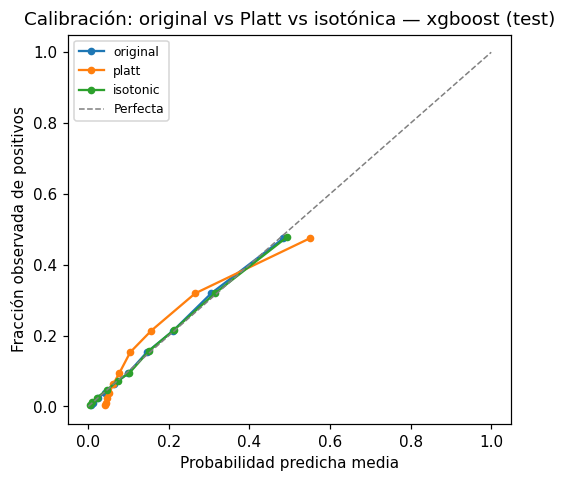

In [3]:
show(RES/'calibration'/'calibration_comparison.png')

In [4]:
s = load(RES/'calibration'/'summary.json')
print('Modelo:', s['best_model'], '| Calibración elegida:', s['chosen_calibration'])

Modelo: xgboost | Calibración elegida: isotonic


### Conclusiones Fase 1C
- La calibración reduce el **Brier** y el **ECE** sin alterar el orden (ROC-AUC), produciendo probabilidades **clínicamente confiables**.
- La **isotónica** suele ganar con muchos datos; Platt es más estable con pocos.
- Estas probabilidades calibradas son el insumo directo de la estratificación de riesgo (NB 04).